## Read in parquet file

In [2]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

df = pd.read_parquet("master_air.parquet")
print(df.shape)
df.head()

/Users/jonzimmerman/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


(58342, 29)


,city_name,continent,country,country_code,display_name,elevation,iata,icao,latitude,longitude,...,source_access_index,dest_num_dests,dest_access_index,source_term,dest_sum,dest_term,access_term_unnorm,access,connect_term_unnorm,connectivity_index
0,Anaa,OC,French Polynesia,PF,"Anaa (AAA), French Polynesia",23.0,AAA,NTGA,-17.355648,-145.50913,...,1.0,39.0,3.0,1.0,117.0,117.0,1.712532,15.081918,1.712532,15.081918
1,Adado,AF,Somalia,SO,"Adado (AAD), Somalia",1005.0,AAD,None,6.095833,46.6375,...,1.0,13.0,2.0,1.0,26.0,26.0,1.343820,10.419373,1.343820,10.419373
2,Annaba,AF,Algeria,DZ,"Annaba (AAE), Algeria",16.0,AAE,DABB,36.821392,7.811857,...,2.0,86.0,4.0,22.0,344.0,6827.0,4.558817,51.074613,4.558817,51.074613
3,Annaba,AF,Algeria,DZ,"Annaba (AAE), Algeria",16.0,AAE,DABB,36.821392,7.811857,...,2.0,271.0,5.0,22.0,1355.0,6827.0,4.558817,51.074613,4.558817,51.074613
4,Annaba,AF,Algeria,DZ,"Annaba (AAE), Algeria",16.0,AAE,DABB,36.821392,7.811857,...,2.0,10.0,2.0,22.0,20.0,6827.0,4.558817,51.074613,4.558817,51.074613


# Let's calculate some metrics and make some plots

### Continents

In [3]:
import matplotlib.pyplot as plt


airports = df[["iata", "continent", "connectivity_index"]].drop_duplicates(subset="iata")

by_continent = airports.groupby("continent")["connectivity_index"].agg(["mean", "median"]).round(2)
by_continent.sort_values(by="mean", ascending=False, inplace=True)
by_continent.head()

,mean,median
continent,,
EU,45.70,38.72
AS,38.94,32.46
NA,30.97,23.49
AF,29.24,21.94
SA,26.52,23.55


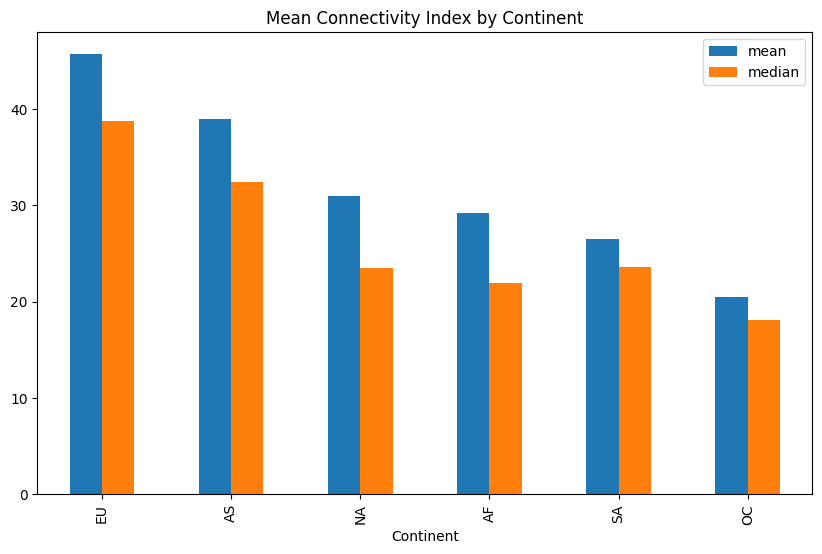

In [4]:
# Plot the mean connectivity index by continent
by_continent.plot(kind="bar", figsize=(10, 6))
plt.title("Mean Connectivity Index by Continent")
plt.xlabel("Continent");

### Countries (EU)

In [5]:
def look_at_metrics_and_then_plot_histograms(continent_filter):

    airports = df[["iata", "country", "continent", "connectivity_index"]].drop_duplicates(subset="iata")
    continent = airports[airports["continent"] == continent_filter]

    by_continent = continent.groupby("country")["connectivity_index"].agg(["mean", "median"]).round(2)
    by_continent.sort_values(by="mean", ascending=False, inplace=True)
    print(by_continent.head(10))

    by_continent = by_continent.head(25)
    by_continent.plot(kind="bar", figsize=(10, 6))
    plt.title(f"Mean Connectivity Index by Country in {continent_filter}")
    plt.xlabel("Country");

               mean  median
country                    
Luxembourg    88.02   88.02
Malta         87.93   87.93
Albania       87.92   87.92
Latvia        84.61   84.61
Sint Maarten  70.40   70.40
Kosovo        70.31   70.31
Montenegro    70.01   70.01
Bulgaria      67.50   73.71
Slovenia      67.44   67.44
Belgium       67.29   69.97


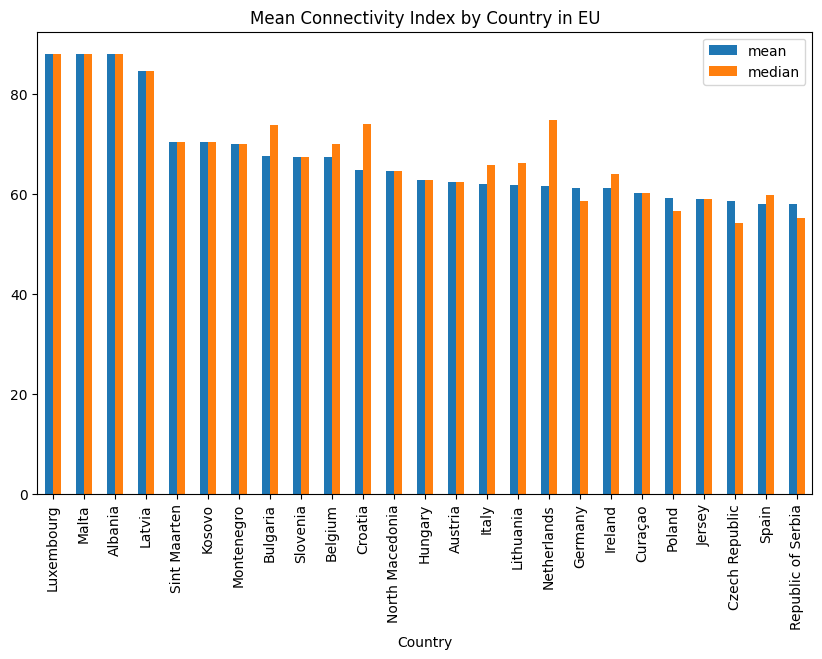

In [6]:
look_at_metrics_and_then_plot_histograms('EU')

## Countries (AS)

                       mean  median
country                            
Qatar                 93.98   93.98
Kuwait                86.27   86.27
Bahrain               78.61   78.61
Lebanon               78.35   78.35
Macau SAR             71.05   71.05
Cyprus                69.98   77.76
United Arab Emirates  64.24   68.58
Brunei Darussalam     58.50   58.50
Georgia               55.25   61.50
Cambodia              55.13   55.13


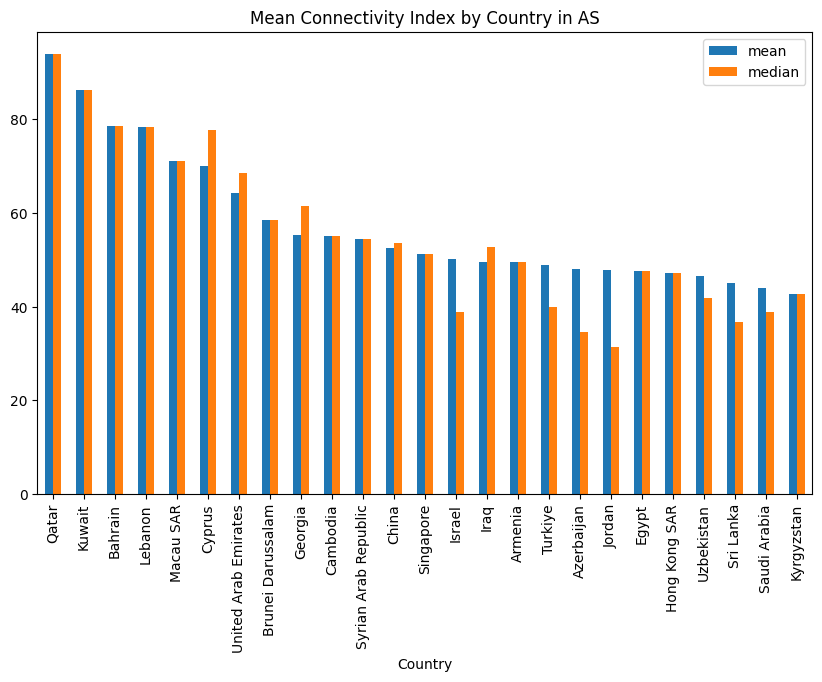

In [7]:
look_at_metrics_and_then_plot_histograms('AS')

                                   mean  median
country                                        
Kyrgyzstan                        70.14   70.14
Aruba                             68.29   68.29
Barbados                          68.19   68.19
El Salvador                       68.06   68.06
Antigua and Barbuda               64.48   64.48
Bermuda                           55.51   55.51
Martinique                        54.47   54.47
Guadeloupe                        54.04   54.04
Dominican Republic                51.89   51.52
Saint Vincent and the Grenadines  51.26   51.26


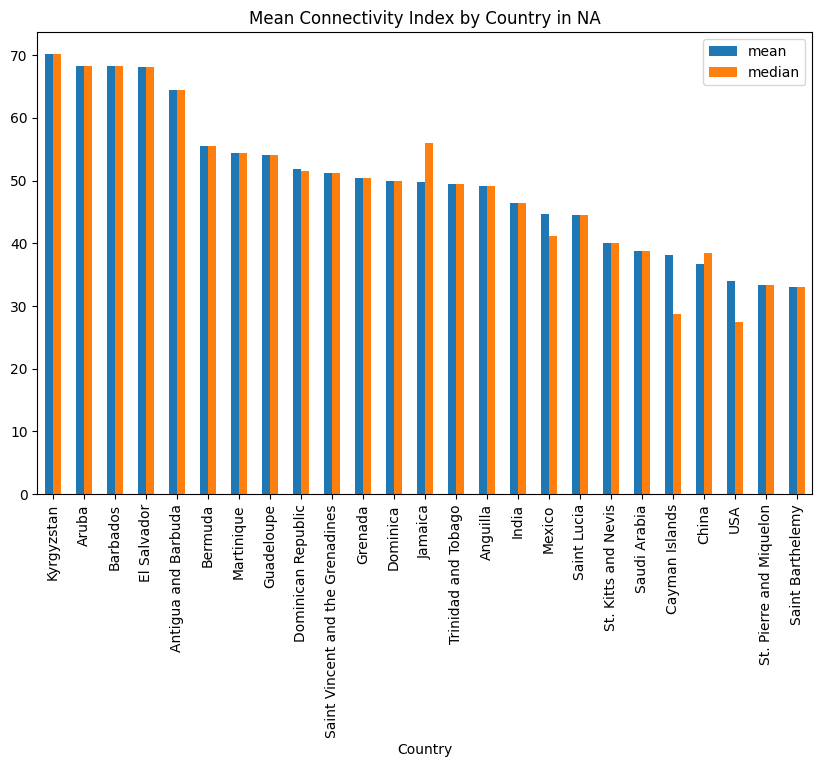

In [8]:
look_at_metrics_and_then_plot_histograms('NA')

            mean  median
country                 
Guyana     40.46   40.46
Suriname   39.37   39.37
Paraguay   34.92   34.92
Argentina  31.18   24.92
Brazil     27.35   23.16
Colombia   26.48   23.75
Uruguay    26.04   18.33
Ecuador    25.62   18.76
Chile      23.63   21.41
Peru       23.03   17.96


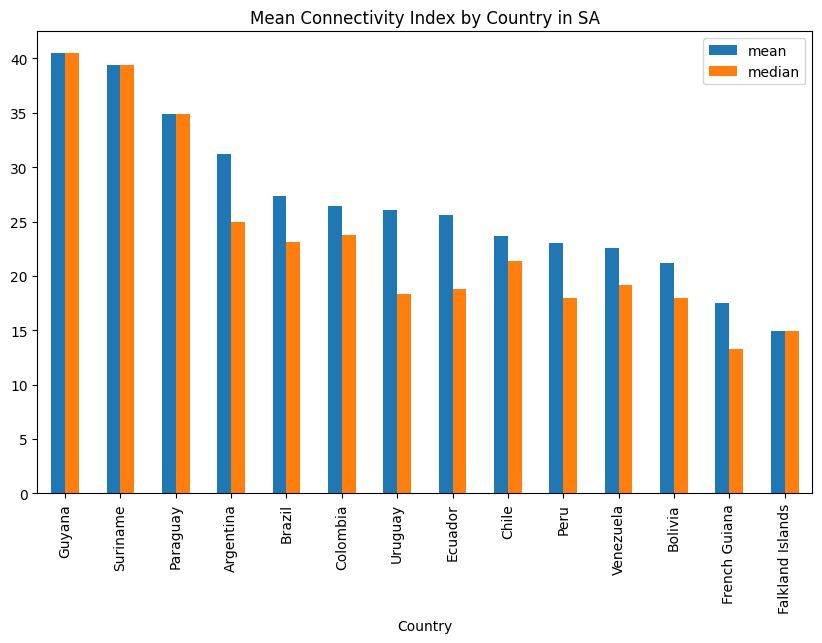

In [9]:
look_at_metrics_and_then_plot_histograms('SA')

           mean  median
country                
Togo      56.87   56.87
Egypt     55.93   58.55
Tunisia   54.57   61.63
Benin     53.77   53.77
Guinea    52.13   52.13
Morocco   52.00   51.28
Gambia    51.74   51.74
Reunion   50.98   50.98
Djibouti  50.47   50.47
Mali      49.42   49.42


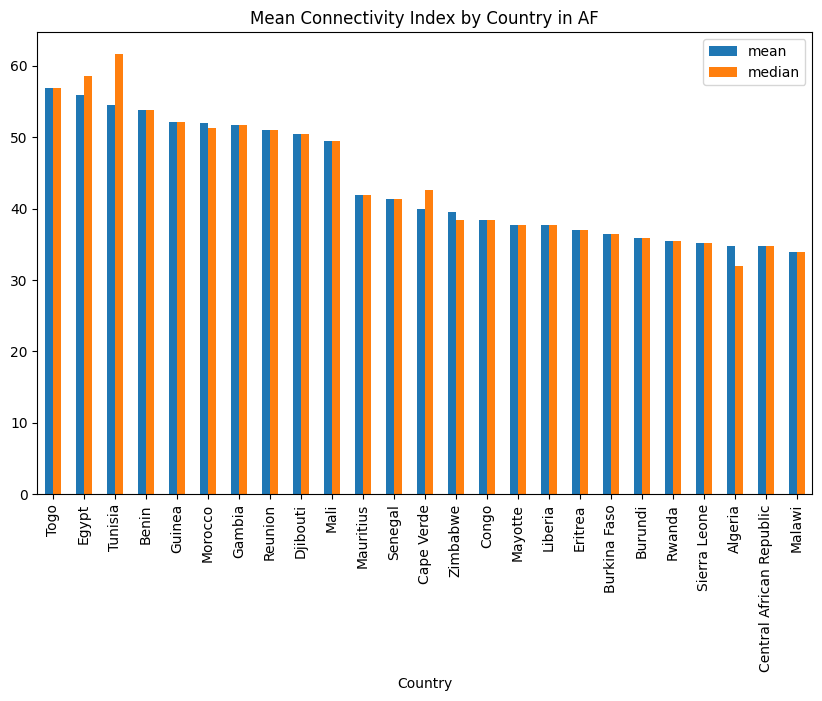

In [10]:
look_at_metrics_and_then_plot_histograms('AF')

                   mean  median
country                        
Guam              52.01   52.01
Palau             38.05   38.05
Samoa             30.10   30.10
East Timor        28.52   28.52
Nauru             28.10   28.10
New Zealand       27.06   24.52
Russia            26.68   26.68
Norfolk Island    24.52   24.52
Australia         22.53   18.89
Papua New Guinea  22.01   20.90


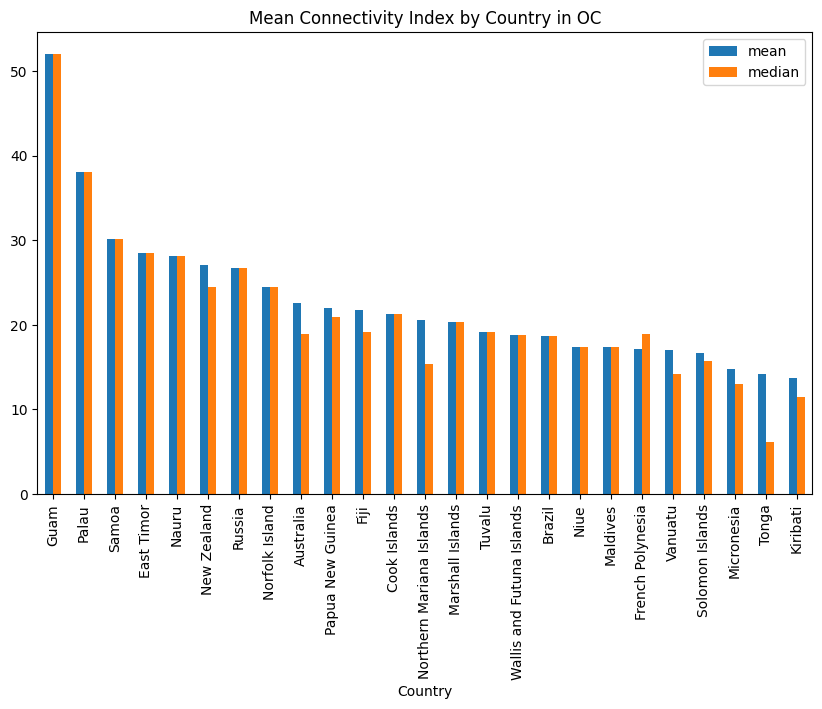

In [11]:
look_at_metrics_and_then_plot_histograms('OC')

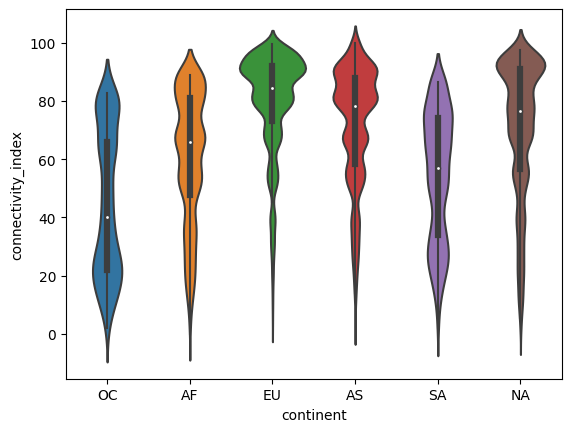

In [12]:
import seaborn as sns
sns.violinplot(data=df, x="continent", y="connectivity_index");

### Airlines

In [23]:
import plotly.express as px

def look_at_the_airlines(iata_code):
    airport = df[df["iata"] == iata_code][["iata", "dest_iata", "carriers"]]
    airport["airline_names"] = airport["carriers"].apply(
        lambda x: list({carrier["name"] for carrier in x})
    )

    airport_exploded = airport.explode("airline_names")
    airport_exploded = airport.explode("airline_names").dropna(subset=["airline_names"])

    fig = px.treemap(
        airport_exploded,
        path=["airline_names", "dest_iata"],
        title=f"{iata_code} Routes by Airline"
    )

    return fig

In [38]:
look_at_the_airlines("STL")

### Making some maps

In [62]:
# Get unique airports to avoid duplicate points (df has one row per route)
airports = df[["iata", "latitude", "longitude", "display_name","elevation", "connectivity_index"]].drop_duplicates(subset="iata")
airports["latitude"] = pd.to_numeric(airports["latitude"], errors="coerce")
airports["longitude"] = pd.to_numeric(airports["longitude"], errors="coerce")
airports = airports.dropna(subset=["latitude", "longitude"])

fig = px.scatter_mapbox(
    airports,
    lat="latitude",
    lon="longitude",
    hover_name="display_name",
    hover_data=["iata", "connectivity_index"],
    color="connectivity_index",
    color_continuous_scale="Viridis",
    zoom=1,
    height=500,
)
fig.update_layout(
    mapbox_style="open-street-map",
    margin=dict(l=10, r=10, t=30, b=10)
)
fig.show()

In [61]:
fig = px.scatter_mapbox(
    airports,
    lat="latitude",
    lon="longitude",
    hover_name="display_name",
    hover_data=["iata", "connectivity_index"],
    color="elevation",
    color_continuous_scale="Viridis",
    zoom=1,
    height=500,
)
fig.update_layout(
    mapbox_style="open-street-map",
    margin=dict(l=10, r=10, t=30, b=10)
)
fig.show()

### Supply chain disruption idea

In [52]:
import numpy as np

def haversine_miles(lat1, lon1, lat2, lon2):
    R = 3959  # Earth radius in miles
    lat1, lon1, lat2, lon2 = np.radians(lat1), np.radians(lon1), np.radians(lat2), np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

In [55]:
# 1. Unique airports - ensure we have one row per airport and valid coords
airports = df[["iata", "latitude", "longitude"]].drop_duplicates(subset="iata")
airports["latitude"] = pd.to_numeric(airports["latitude"], errors="coerce")
airports["longitude"] = pd.to_numeric(airports["longitude"], errors="coerce")
airports = airports.dropna(subset=["latitude", "longitude"]).reset_index(drop=True)

n = len(airports)
lats = airports["latitude"].values
lons = airports["longitude"].values

# 2. Compute distances (loop uses same n as airports)
nearest_mi = []
within_10 = []
within_25 = []
within_50 = []
within_100 = []

for i in range(n):
    dists = haversine_miles(lats[i], lons[i], lats, lons)
    dists[i] = np.inf  # exclude self
    nearest_mi.append(np.min(dists))
    within_10.append(np.sum(dists <= 10))
    within_25.append(np.sum(dists <= 25))
    within_50.append(np.sum(dists <= 50))
    within_100.append(np.sum(dists <= 100))

# 3. Assign (list lengths must match n)
airports["nearest_airport_miles"] = nearest_mi
airports["airports_within_10_mi"] = within_10
airports["airports_within_25_mi"] = within_25
airports["airports_within_50_mi"] = within_50
airports["airports_within_100_mi"] = within_100

In [56]:
# Keep only the new columns when merging
dist_cols = ["nearest_airport_miles", "airports_within_10_mi", "airports_within_25_mi", 
             "airports_within_50_mi", "airports_within_100_mi"]
df = df.merge(airports[["iata"] + dist_cols], on="iata", how="left")

In [ ]:
# Get unique airports to avoid duplicate points (df has one row per route)
airports = df[["iata", "latitude", "longitude", "display_name","nearest_airport_miles","elevation", "connectivity_index"]].drop_duplicates(subset="iata")
airports["latitude"] = pd.to_numeric(airports["latitude"], errors="coerce")
airports["longitude"] = pd.to_numeric(airports["longitude"], errors="coerce")
airports = airports.dropna(subset=["latitude", "longitude"])

fig = px.scatter_mapbox(
    airports,
    lat="latitude",
    lon="longitude",
    hover_name="display_name",
    hover_data=["iata", "nearest_airport_miles"],
    color="nearest_airport_miles",
    color_continuous_scale="Viridis",
    zoom=1,
    height=500,
)
fig.update_layout(
    mapbox_style="open-street-map",
    margin=dict(l=10, r=10, t=30, b=10)
)
fig.show()